[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lizcodd/fastq2pheno_workshop/blob/main/03_differential/differential_atac.ipynb)

# Differential accessibility: is ecDNA more accessible?

ATAC-seq of two versions of the colorectal cancer line COLO320, from
[Wu et al. 2019, *Nature*](https://www.nature.com/articles/s41586-019-1763-5), two replicates each:

- **COLO320DM**: the *MYC* oncogene is amplified on **ecDNA**, small circles of DNA outside the chromosomes known to drive tumor evolution and drug resistance
- **COLO320HSR**: the same amplified DNA is **integrated into a chromosome**

The paper's claim: ecDNA is more accessible than the same DNA in a chromosome. Starting from Step 2's table of
reads per peak per sample, we will:

1. Find the peaks that differ between the lines.
2. Ask whether more reads means more accessible: copy number.
3. Look at what differs beyond the amplicon, and which transcription factors are involved.

Cells marked **✏️ Try it** have settings to change and re-run.

*In Colab the badge above starts an **R** runtime (if it doesn't: Runtime → Change runtime type → R). Then run the cells in order.*

## 0. Setup (about 3 minutes)

In [1]:
# Install the R packages (prebuilt binaries from r2u, so this takes about a minute instead of 20)
needed <- c("DESeq2", "dplyr", "tidyr", "ggplot2", "patchwork")
if (!all(sapply(needed, requireNamespace, quietly = TRUE))) {
    codename <- system("lsb_release -cs", intern = TRUE)
    download.file(sprintf("https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_%s.sh", codename), "add_cranapt.sh")
    system("bash add_cranapt.sh > /dev/null")
    bspm::enable(); options(bspm.version.check = FALSE)
    install.packages(needed)
}
suppressPackageStartupMessages({ library(DESeq2); library(dplyr); library(ggplot2); library(patchwork) })
theme_set(theme_bw(base_size = 15))
options(repr.plot.width = 9, repr.plot.height = 5.5)

In [2]:
# Install HOMER, for the motif analysis at the end (about a minute; no genome needed)
if (system("which findMotifs.pl", ignore.stdout = TRUE) != 0) {
    dir.create("homer", showWarnings = FALSE)
    download.file("http://homer.ucsd.edu/homer/configureHomer.pl", "homer/configureHomer.pl")
    system("cd homer && perl configureHomer.pl -install homer > install.log 2>&1")
    Sys.setenv(PATH = paste(file.path(getwd(), "homer/bin"), Sys.getenv("PATH"), sep = ":"))
}
system("which findMotifs.pl")

In [3]:
# Download the data (one archive on Google Drive, about 12 MB) and unpack it into data/
drive_file_id <- "1oVtCZvKucNm6xm2qVrCtrRdCSp_erdUY"
if (!file.exists("data/peaks.tsv.gz")) {
    url <- sprintf("https://drive.usercontent.google.com/download?id=%s&export=download&confirm=t", drive_file_id)
    download.file(url, "differential_atac_data.tar.gz", mode = "wb")
    untar("differential_atac_data.tar.gz")
}
list.files("data")

[1] "amplicon_segments.tsv"  "bins_10kb.tsv.gz"       "copy_number_1mb.tsv.gz"
[4] "fragment_gc.tsv.gz"     "library_qc.tsv"         "myc_region_genes.tsv"  
[7] "peaks_200bp.fa.gz"      "peaks.tsv.gz"

## 1. The data

One row per peak: where it is, a few annotations, and each sample's read count.

In [4]:
peaks <- read.delim("data/peaks.tsv.gz")
samples <- c("COLO320DM_REP1", "COLO320DM_REP2", "COLO320HSR_REP1", "COLO320HSR_REP2")
nrow(peaks)
head(peaks[, c("chr", "start", "end", "gc", "feature", "gene", samples)])

[1] 107271

,chr,start,end,gc,feature,gene,COLO320DM_REP1,COLO320DM_REP2,COLO320HSR_REP1,COLO320HSR_REP2
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,chr1,10073,10659,0.5767918,Intergenic,DDX11L2,37,44,21,38
2,chr1,29000,29320,0.7687500,promoter-TSS,MIR1302-2HG,5,3,0,1
3,chr1,180753,181950,0.6783626,Intergenic,ENSG00000241860,66,101,53,76
4,chr1,267740,268082,0.5029240,intron,ENSG00000286448,25,27,13,16
5,chr1,733834,734063,0.4104803,intron,ENSG00000229905,1,4,1,8
6,chr1,736537,736960,0.4586288,intron,ENSG00000229905,16,16,7,19


**Which peaks?** The pipeline keeps a region if MACS2 called it a peak in *any one* of the four samples, and many
of those barely rise above the background. As with lowly expressed genes in RNA-seq, drop the weak ones before testing.

**✏️ Try it.** Change `min_reads_per_million`. 2 is about 10 reads in the smallest library here.

In [5]:
min_reads_per_million <- 2

reads_per_million <- rowMeans(sweep(as.matrix(peaks[, samples]), 2, colSums(peaks[, samples]), "/")) * 1e6
keep <- reads_per_million >= min_reads_per_million
peaks <- peaks[keep, ]
nrow(peaks)  # number of peaks kept after filtering

[1] 71496

## 2. Differential peaks

DESeq2 treats each peak like a gene: it normalizes for sequencing depth, estimates how much counts vary
between replicates, and tests each peak for a difference between the lines.

In [6]:
counts <- as.matrix(peaks[, samples])
rownames(counts) <- peaks$peak
sample_info <- data.frame(line = factor(c("DM", "DM", "HSR", "HSR"), levels = c("HSR", "DM")),   # HSR is the reference
                          row.names = samples)
dds <- DESeqDataSetFromMatrix(counts, sample_info, design = ~ line)
dds <- DESeq(dds, fitType = "local", quiet = TRUE)     # about a minute

**✏️ Try it.** A peak is differential if its adjusted p-value is below `padj_cutoff` and its fold change is large
enough. `test_fold_change = TRUE` tests directly whether the change is bigger than `lfc_cutoff` (stricter, better
with two replicates); `FALSE` tests for any change and filters on fold change afterwards. How many peaks does each give?

In [7]:
padj_cutoff <- 0.05
lfc_cutoff <- 1              # log2 fold change: 1 means 2-fold
test_fold_change <- TRUE

call_peaks <- function(dds) {
    res <- results(dds, alpha = padj_cutoff, lfcThreshold = if (test_fold_change) lfc_cutoff else 0)
    call <- case_when(
        res$padj < padj_cutoff & res$log2FoldChange >  lfc_cutoff ~ "up in DM",
        res$padj < padj_cutoff & res$log2FoldChange < -lfc_cutoff ~ "up in HSR",
        TRUE ~ "not significant")
    data.frame(peak = rownames(res), log2FC = res$log2FoldChange, padj = res$padj, call = call)
}
naive <- call_peaks(dds)
table(naive$call)


not significant        up in DM       up in HSR 
          62360            2264            6872 

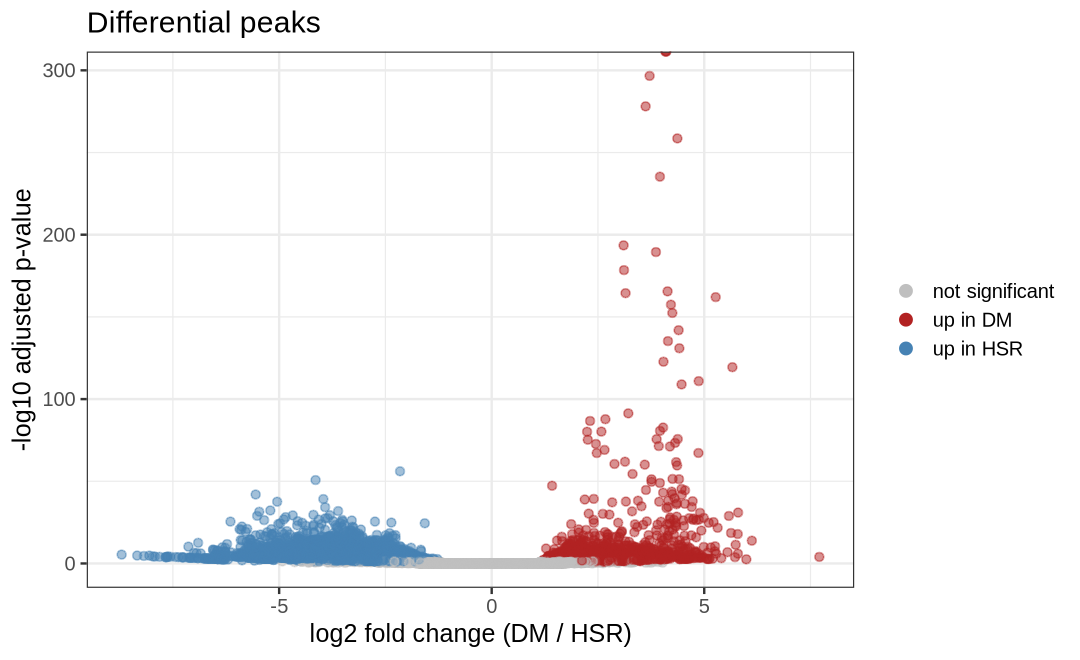

In [8]:
call_colors <- c("not significant" = "gray75", "up in DM" = "firebrick", "up in HSR" = "steelblue")

ggplot(filter(naive, !is.na(padj)), aes(log2FC, -log10(padj), color = call)) +
    geom_point(size = 2, alpha = 0.5) +
    scale_color_manual(values = call_colors) +
    guides(color = guide_legend(override.aes = list(size = 3, alpha = 1))) +
    labs(x = "log2 fold change (DM / HSR)", y = "-log10 adjusted p-value", color = NULL,
         title = "Differential peaks")

Thousands of peaks differ, but the most extreme ones are all "up in DM". Where are they?

## 3. Copy number

The *MYC* amplicon on chr8: each line's copy number from whole-genome sequencing (top) and each peak's fold change (bottom).

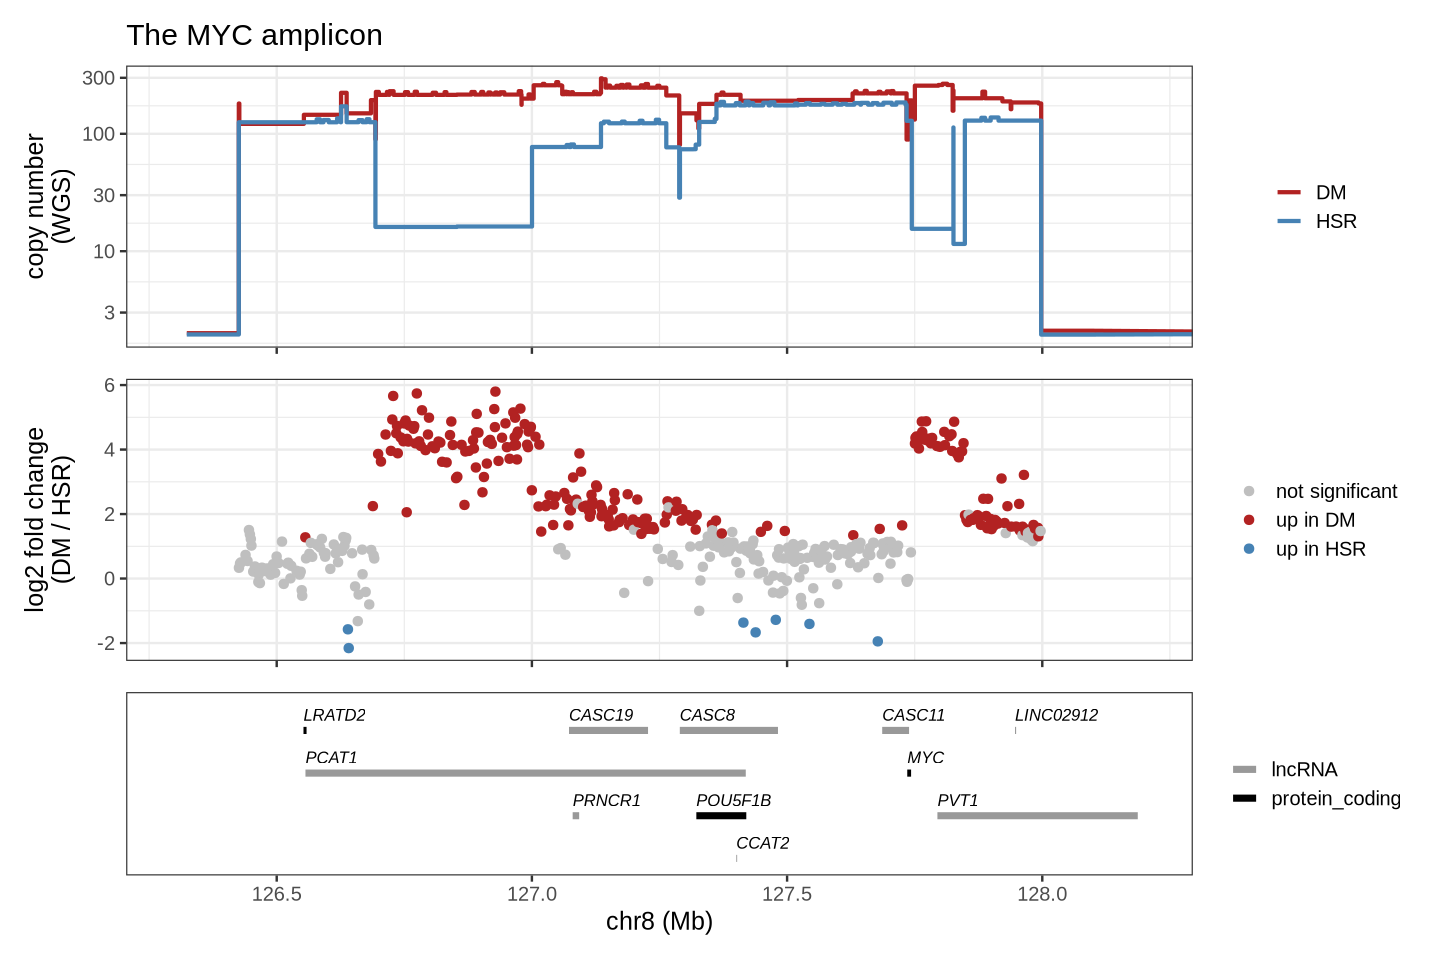

In [9]:
segments <- read.delim("data/amplicon_segments.tsv")
genes <- read.delim("data/myc_region_genes.tsv")
myc_peaks <- naive |> mutate(chr = peaks$chr, start = peaks$start) |> filter(chr == "chr8", start > 126.3e6, start < 128.2e6)
region <- c(126.3, 128.2)       # Mb

# copy number as a connected step line: each segment's start and end, in order along the chromosome
steps <- segments |> arrange(line, start) |>
    tidyr::pivot_longer(c(start, end), values_to = "position") |> arrange(line, position)

# genes: put each gene in the first row where it doesn't overlap the gene (or label) before it
genes <- genes |> mutate(from = pmax(start, region[1] * 1e6) / 1e6, to = pmin(end, region[2] * 1e6) / 1e6) |> arrange(from)
row_end <- c(); genes$row <- NA
for (i in seq_len(nrow(genes))) {
    label_end <- genes$from[i] + 0.02 * nchar(genes$name[i])       # rough width of the label, in Mb
    r <- which(row_end < genes$from[i])[1]
    if (is.na(r)) r <- length(row_end) + 1
    genes$row[i] <- r; row_end[r] <- max(genes$to[i], label_end) + 0.03
}

cn_panel <- ggplot(steps, aes(position / 1e6, copy_number, color = line)) + geom_path(linewidth = 1.2) +
    scale_y_log10() + scale_color_manual(values = c(DM = "firebrick", HSR = "steelblue")) +
    labs(x = NULL, y = "copy number\n(WGS)", color = NULL, title = "The MYC amplicon") +
    theme(axis.text.x = element_blank())
fc_panel <- ggplot(myc_peaks, aes(start / 1e6, log2FC, color = call)) + geom_point() +
    scale_color_manual(values = call_colors) +
    labs(x = NULL, y = "log2 fold change\n(DM / HSR)", color = NULL) +
    theme(axis.text.x = element_blank())
gene_panel <- ggplot(genes) +
    geom_segment(aes(x = from, xend = to, y = -row, yend = -row, color = type), linewidth = 2) +
    geom_text(aes(x = from, y = -row, label = name), size = 3.5, hjust = 0, vjust = -0.8, fontface = "italic") +
    scale_color_manual(values = c(protein_coding = "black", lncRNA = "gray60")) +
    scale_y_continuous(expand = expansion(add = c(0.4, 0.9))) +
    labs(x = "chr8 (Mb)", y = NULL, color = NULL) +
    theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), panel.grid = element_blank())

options(repr.plot.width = 12, repr.plot.height = 8)
(cn_panel / fc_panel / gene_panel) + plot_layout(heights = c(2, 2, 1.3)) & coord_cartesian(xlim = region)
options(repr.plot.width = 9, repr.plot.height = 5.5)

Where HSR has fewer copies (the dips in its line), DM's peaks are "up" 10-fold or more: roughly the difference in
copy number. More copies of DNA give more reads without being more accessible.

**Add copy number to the model.** Give DESeq2 a normalization factor for every peak and sample: the sample's size
factor times its line's copy number at that peak. Twice the copies, twice the expected reads.

In [10]:
copy_number <- cbind(peaks$copy_ratio_DM, peaks$copy_ratio_DM, peaks$copy_ratio_HSR, peaks$copy_ratio_HSR)
has_cn <- complete.cases(copy_number)

dds_cn <- DESeqDataSetFromMatrix(counts[has_cn, ], sample_info, design = ~ line)
factors <- matrix(sizeFactors(dds), nrow(counts), 4, byrow = TRUE)[has_cn, ] * copy_number[has_cn, ]
normalizationFactors(dds_cn) <- factors / exp(rowMeans(log(factors)))
dds_cn <- DESeq(dds_cn, fitType = "local", quiet = TRUE)

cn_corrected <- call_peaks(dds_cn)
cn_corrected$region_class <- peaks$region_class[has_cn]

bind_rows("standard" = mutate(naive, region_class = peaks$region_class),
          "with copy number" = cn_corrected, .id = "analysis") |>
    mutate(where = ifelse(startsWith(region_class, "off"), "off amplicons", "on amplicons")) |>
    count(where, analysis, call) |>
    tidyr::pivot_wider(names_from = call, values_from = n, values_fill = 0)

where,analysis,not significant,up in DM,up in HSR
<chr>,<chr>,<int>,<int>,<int>
off amplicons,standard,61981,2022,6851
off amplicons,with copy number,62429,1369,6962
on amplicons,standard,379,242,21
on amplicons,with copy number,572,33,37


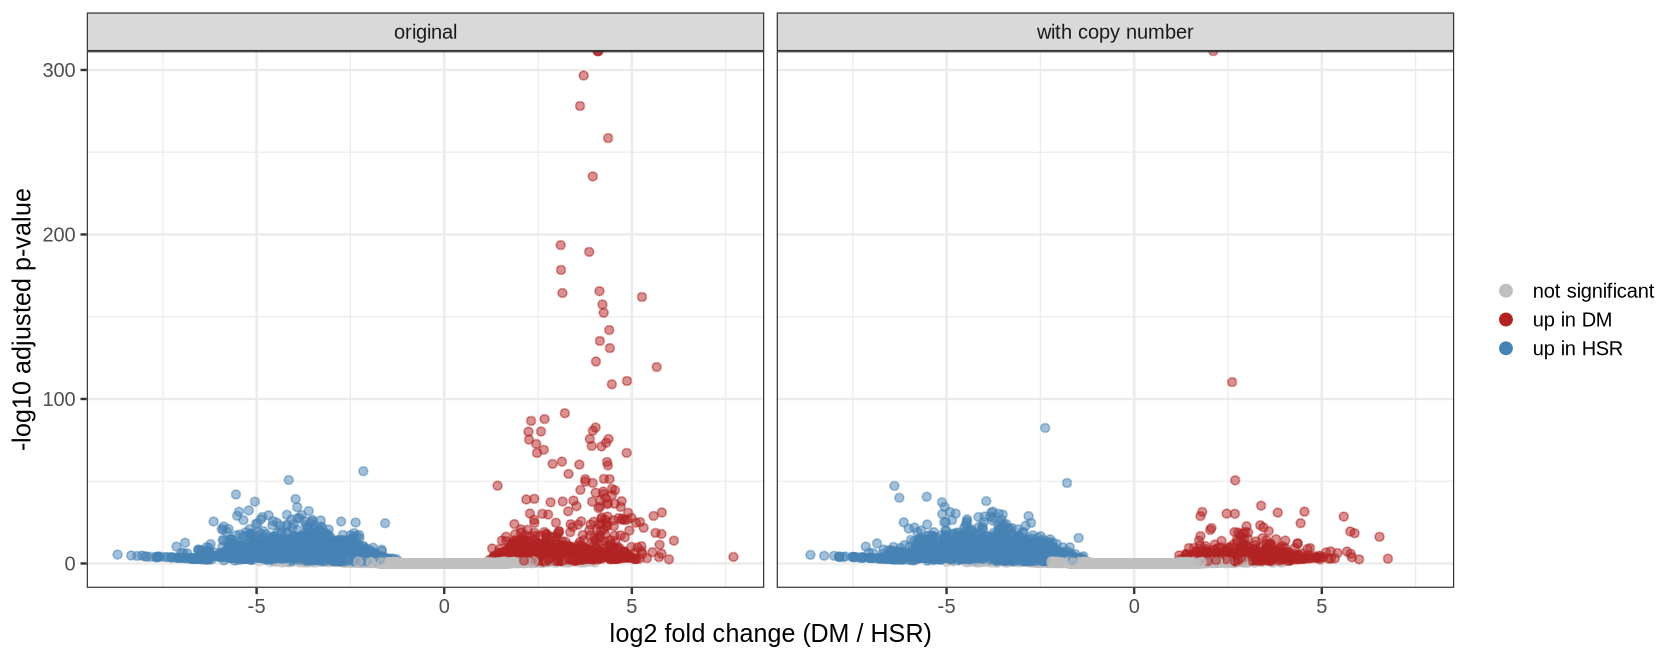

In [11]:
volcano <- bind_rows("original" = select(naive, log2FC, padj, call),
                     "with copy number" = select(cn_corrected, log2FC, padj, call), .id = "analysis") |>
    filter(!is.na(padj)) |>
    mutate(neg_log10_padj = -log10(padj))
options(repr.plot.width = 14, repr.plot.height = 5.5)
ggplot(volcano, aes(log2FC, neg_log10_padj, color = call)) +
    geom_point(aes(size = 2), alpha = 0.5) + scale_size_identity() + facet_wrap(~ analysis) +
    scale_color_manual(values = call_colors) +
    guides(color = guide_legend(override.aes = list(size = 3, alpha = 1))) +
    labs(x = "log2 fold change (DM / HSR)", y = "-log10 adjusted p-value", color = NULL)
options(repr.plot.width = 9, repr.plot.height = 5.5)

With copy number in the model, the tower of amplicon peaks is gone. Most of the differences that remain are off the amplicons.

### Per copy, is ecDNA more accessible?

Reproduce the paper's measure: ATAC reads in 10 kb windows divided by copy number, relative to a typical window elsewhere in
the genome.

where,windows,DM,HSR
<chr>,<int>,<dbl>,<dbl>
MYC amplicon,157,2.082444,1.046196
rest of genome,30000,1.000000,1.000000


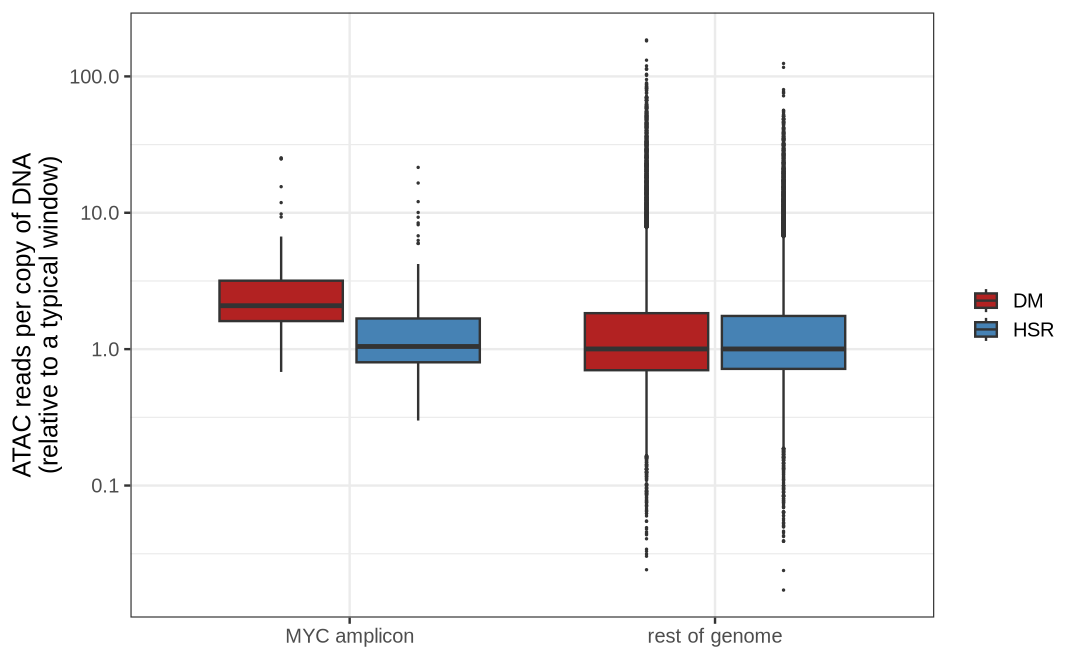

In [12]:
bins <- read.delim("data/bins_10kb.tsv.gz")
atac <- bins[, grep("_peaks_", names(bins))]           # ATAC reads in peaks + between peaks
atac_total <- sapply(c("DM_REP1", "DM_REP2", "HSR_REP1", "HSR_REP2"), function(s) rowSums(atac[, grep(s, names(atac))]))
atac_cpm <- sweep(atac_total, 2, colSums(atac_total), "/") * 1e6

per_copy <- data.frame(
    where = ifelse(bins$myc_amplicon, "MYC amplicon", "rest of genome"),
    DM  = rowMeans(atac_cpm[, 1:2]) / (bins$wgs_DM  / median(bins$wgs_DM)),
    HSR = rowMeans(atac_cpm[, 3:4]) / (bins$wgs_HSR / median(bins$wgs_HSR)))
per_copy$DM  <- per_copy$DM  / median(per_copy$DM[per_copy$where == "rest of genome"])
per_copy$HSR <- per_copy$HSR / median(per_copy$HSR[per_copy$where == "rest of genome"])

per_copy |> group_by(where) |> summarize(windows = n(), DM = median(DM), HSR = median(HSR))
per_copy |> tidyr::pivot_longer(c(DM, HSR), names_to = "line", values_to = "per_copy") |>
    filter(per_copy > 0) |>
    ggplot(aes(where, per_copy, fill = line)) + geom_boxplot(outlier.size = 0.3) + scale_y_log10() +
    scale_fill_manual(values = c(DM = "firebrick", HSR = "steelblue")) +
    labs(x = NULL, y = "ATAC reads per copy of DNA\n(relative to a typical window)", fill = NULL)

Per copy, the amplicon is about twice as accessible on ecDNA (DM) as in the chromosome (HSR), as the paper reported.
Copy number explained the 10-fold and larger differences; this 2-fold remainder sits right at `lfc_cutoff`, so the
peak-by-peak test above calls few amplicon peaks.

## 4. Beyond the amplicon

Most differential peaks are where the two lines have the same copy number. Where are they, and how GC-rich?

call,peaks,median_gc,percent_below_40_GC
<chr>,<int>,<dbl>,<dbl>
not significant,63001,0.41,45
up in DM,1402,0.40,51
up in HSR,6999,0.37,77


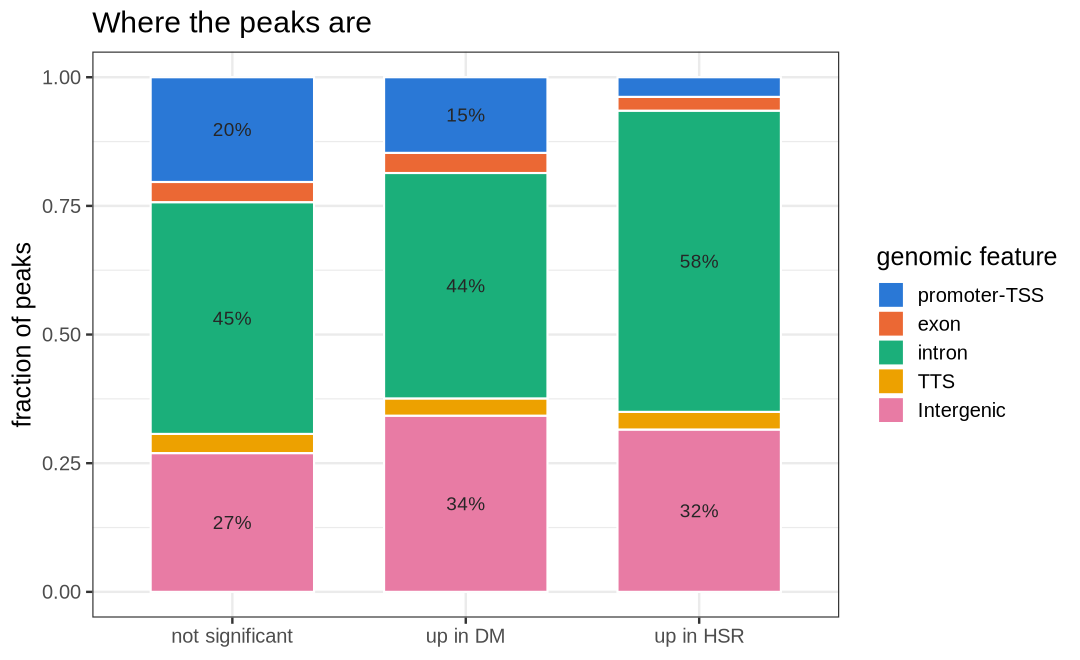

In [13]:
left <- cn_corrected |> mutate(feature = peaks$feature[has_cn], gc = peaks$gc[has_cn])

feature_colors <- c("promoter-TSS" = "#2a78d6", "exon" = "#eb6834", "intron" = "#1baf7a", "TTS" = "#eda100", "Intergenic" = "#e87ba4")
left |> count(call, feature) |> group_by(call) |> mutate(fraction = n / sum(n)) |>
    mutate(feature = factor(feature, levels = names(feature_colors))) |>
    ggplot(aes(call, fraction, fill = feature)) + geom_col(color = "white", linewidth = 0.6, width = 0.7) +
    geom_text(aes(label = ifelse(fraction >= 0.05, paste0(round(100 * fraction), "%"), "")),
              position = position_stack(vjust = 0.5), size = 4, color = "gray15") +
    scale_fill_manual(values = feature_colors) +
    labs(x = NULL, y = "fraction of peaks", fill = "genomic feature", title = "Where the peaks are")
left |> group_by(call) |> summarize(peaks = n(), median_gc = round(median(gc), 2), percent_below_40_GC = round(100 * mean(gc < 0.4)))

Peaks up in HSR are rarely promoters and mostly AT-rich. GC content is a classic technical bias: PCR copies some
GC levels better than others, differently in each batch. Median fold change in 20 bins of peak GC:

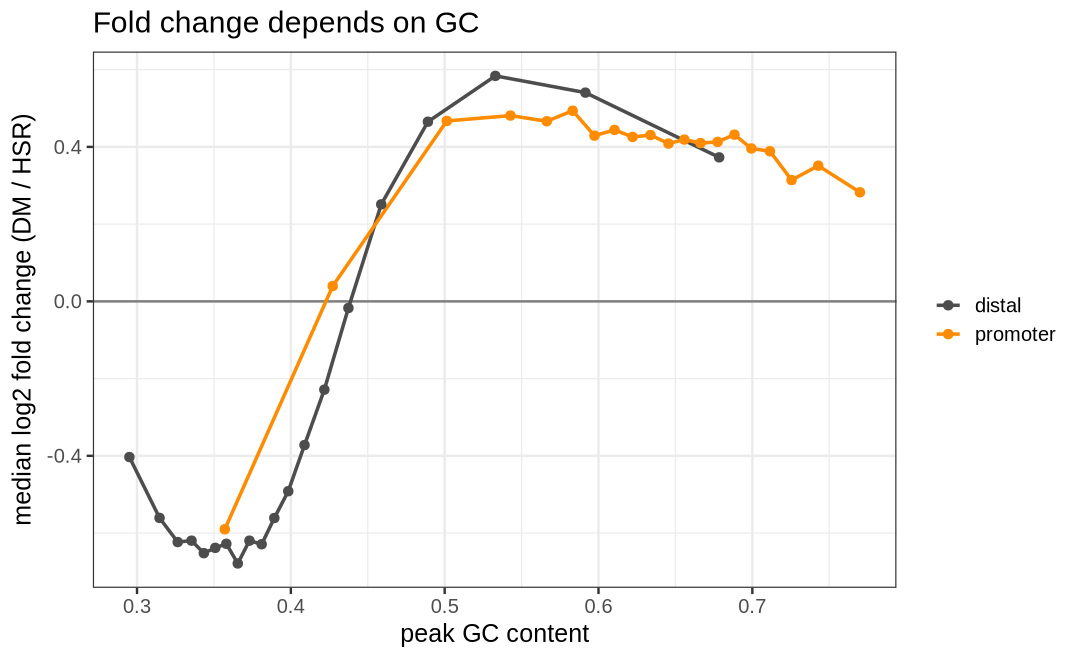

In [14]:
gc_trend <- left |>
    filter(!is.na(log2FC)) |>
    mutate(type = ifelse(feature == "promoter-TSS", "promoter", "distal")) |>
    group_by(type) |> mutate(gc_bin = ntile(gc, 20)) |>
    group_by(type, gc_bin) |> summarize(gc = median(gc), median_log2FC = median(log2FC), .groups = "drop")
ggplot(gc_trend, aes(gc, median_log2FC, color = type)) +
    geom_hline(yintercept = 0, color = "gray50") + geom_line(linewidth = 1) + geom_point() +
    scale_color_manual(values = c(distal = "gray30", promoter = "darkorange")) +
    labs(x = "peak GC content", y = "median log2 fold change (DM / HSR)", color = NULL,
         title = "Fold change depends on GC")

A sharp step between about 40% and 50% GC, in promoters and distal peaks alike.

### Is it PCR?

PCR acts on every fragment, open chromatin or not, so a PCR bias would also show up in the background. This plot
compares DM and HSR fragment by fragment, in peaks and for nucleosome-sized (180–250 bp) background fragments, in
regions with equal copy number.

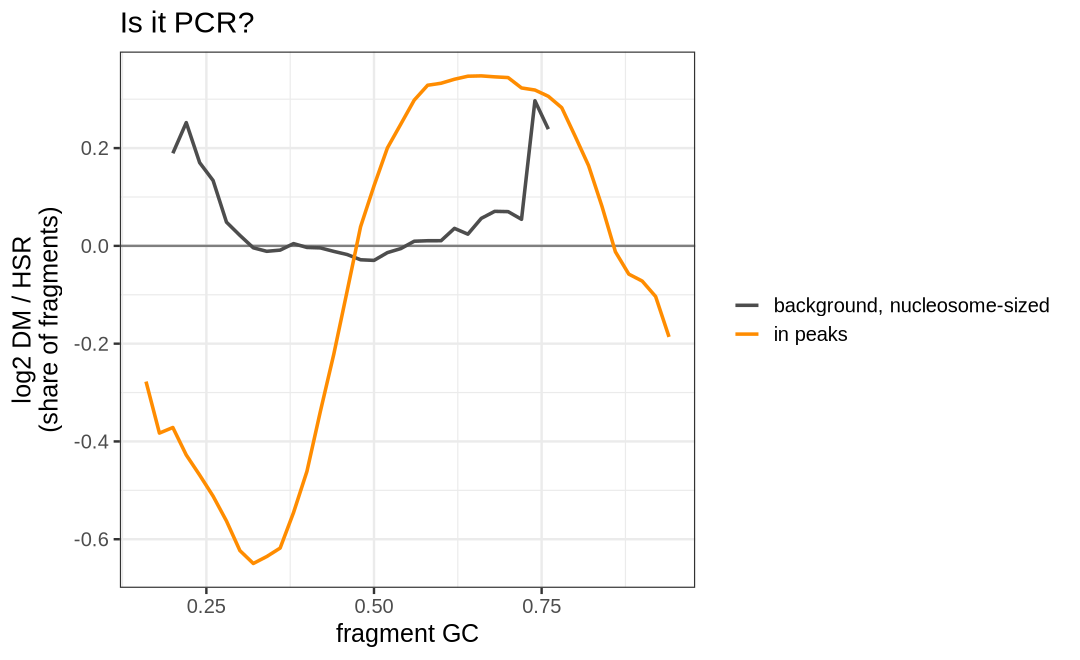

In [15]:
frag <- read.delim("data/fragment_gc.tsv.gz") |>
    filter(location == "peak" | (location == "background" & length >= 180 & length < 250)) |>
    mutate(fragments = ifelse(location == "peak", "in peaks", "background, nucleosome-sized"),
           line = ifelse(grepl("DM", sample), "DM", "HSR")) |>
    group_by(fragments, line, gc) |> summarize(n = sum(n), .groups = "drop") |>
    group_by(fragments, line) |> mutate(share = n / sum(n)) |> ungroup() |>          # each line's share of fragments at each GC
    tidyr::pivot_wider(names_from = line, values_from = c(n, share)) |>
    filter(n_DM >= 500, n_HSR >= 500)                                                # enough fragments for a stable ratio

ggplot(frag, aes(gc, log2(share_DM / share_HSR), color = fragments)) +
    geom_hline(yintercept = 0, color = "gray50") + geom_line(linewidth = 1) +
    scale_color_manual(values = c("in peaks" = "darkorange", "background, nucleosome-sized" = "gray30")) +
    labs(x = "fragment GC", y = "log2 DM / HSR\n(share of fragments)", color = NULL, title = "Is it PCR?")

Only fragments in peaks show the step (the ends of the lines have few fragments). **It isn't PCR.**

### Other biases that could bite

| Bias | What it does | Here |
|---|---|---|
| **Depth** | More reads overall, more in every peak | DESeq2's size factors |
| **Copy number** | More copies of DNA, more reads | in the model; the plot above uses regions with equal copy number |
| **PCR** | Copies some GC levels better than others | background fragments are flat (above) |
| **Signal-to-noise** | Peaks stand out less in a noisier library | the two HSR replicates differ in FRiP (0.43 vs 0.49) but show no GC step between them |
| **Tn5 preference** | Tn5 cuts some sequences more than others | the same cut-site sequence profile in all four libraries |
| **Batch** | Many small differences between prep days | an independent single-cell dataset of these lines ([Hung et al. 2021](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE160148)) shows the same pattern |

Checked for these explanations on aligned reads, and none explains the GC pattern. It looks like a real difference between
the lines, so we don't correct for GC here.

### Look at them in IGV

A list of peaks is only numbers. In a genome browser, check that a "differential" peak looks different in both
replicates and isn't a spike of a few reads. The next cell saves two kinds of file (in Colab: the folder icon on the left, then
right-click → Download):

- `up_in_DM.bed` and `up_in_HSR.bed`: each set of differential peaks (red = up in DM, blue = up in HSR). Drag
  them into the IGV session from Step 2 (`igv_local`).
- `differential_peaks.tsv`: every peak's results, to sort and filter in Excel or R (not for IGV).

In [16]:
diff_peaks <- cn_corrected |>
    mutate(chr = peaks$chr[has_cn], start = peaks$start[has_cn], end = peaks$end[has_cn], gene = peaks$gene[has_cn])
for (set in c("up in DM", "up in HSR")) {
    x <- filter(diff_peaks, call == set) |> arrange(chr, start)
    color <- if (set == "up in DM") "178,34,34" else "70,130,180"
    writeLines(c(sprintf('track name="%s" itemRgb="On"', set),
                 sprintf("%s\t%d\t%d\t%s|log2FC=%.1f\t0\t.\t%d\t%d\t%s", x$chr, x$start, x$end, x$gene, x$log2FC, x$start, x$end, color)),
               paste0(gsub(" ", "_", set), ".bed"))
}

# every peak's results, one row per peak
diff_peaks |>
    transmute(peak, chr, start, end, gene, feature = peaks$feature[has_cn], region_class, gc = round(peaks$gc[has_cn], 3),
              log2FC = round(log2FC, 3), padj = signif(padj, 3), call) |>
    bind_cols(as.data.frame(counts[has_cn, ])) |>                           # the four raw read counts
    write.table("differential_peaks.tsv", sep = "\t", quote = FALSE, row.names = FALSE)
list.files(pattern = "\\.bed$|differential_peaks")

[1] "differential_peaks.tsv" "up_in_DM.bed"           "up_in_HSR.bed"

**✏️ Try it.** Paste a location into IGV's search box. These are the most significant peaks with equal copy
number, so the coverage heights are comparable.

In [17]:
look_at <- "up in HSR"      # or "up in DM"

diff_peaks |>
    filter(call == look_at, region_class == "off-amplicon, CN equal") |>
    arrange(padj) |> head(10) |>
    transmute(igv_location = sprintf("%s:%d-%d", chr, start - 2000, end + 2000), gene,
              log2FC = round(log2FC, 1), padj = signif(padj, 2))

,igv_location,gene,log2FC,padj
,<chr>,<chr>,<dbl>,<dbl>
1,chr2:119185632-119190402,C1QL2,-5.5,2.7e-41
2,chr6:73336901-73342558,DPPA5,-3.9,1.3e-38
3,chrX:22297891-22302972,CBLL2,-4.9,6.0e-32
4,chr7:54151567-54156477,ENSG00000280920,-5.1,8.5e-31
5,chr8:17841874-17848083,ENSG00000253671,-3.5,2.0e-30
6,chr14:69877258-69883239,SLC10A1,-4.0,2.8e-29
7,chr19:51686626-51692888,SPACA6,-4.1,5.7e-29
8,chr22:46076308-46082709,MIRLET7BHG,-3.8,1.3e-28
9,chr2:46479209-46483959,TMEM247,-3.5,2.3e-27


## 5. Which transcription factors? Motif enrichment with HOMER

HOMER counts how often each known TF motif occurs in a set of peaks compared with unchanged peaks, matching their
GC content so the GC pattern doesn't simply turn into "AT-rich motifs up in HSR".

**✏️ Try it.** `regions`: all peaks, or only those off the amplicons with equal copy number.

In [18]:
regions <- "off-amplicon, CN equal"      # or "all"

seqs <- readLines("data/peaks_200bp.fa.gz")
sequences <- setNames(seqs[c(FALSE, TRUE)], sub("^>", "", seqs[c(TRUE, FALSE)]))

results_now <- cn_corrected
if (regions != "all") results_now <- filter(results_now, region_class == regions)

write_fasta <- function(ids, file) writeLines(paste0(">", ids, "\n", sequences[ids]), file)
write_fasta(results_now$peak[results_now$call == "up in DM"], "up_in_DM.fa")
write_fasta(results_now$peak[results_now$call == "up in HSR"], "up_in_HSR.fa")
unchanged <- results_now$peak[results_now$call == "not significant" & !is.na(results_now$padj) & results_now$padj > 0.5]
set.seed(1)
write_fasta(sample(unchanged, min(20000, length(unchanged))), "background.fa")    # 20,000 unchanged peaks are plenty, and much faster
table(results_now$call)


not significant        up in DM       up in HSR 
          50571            1007            5561 

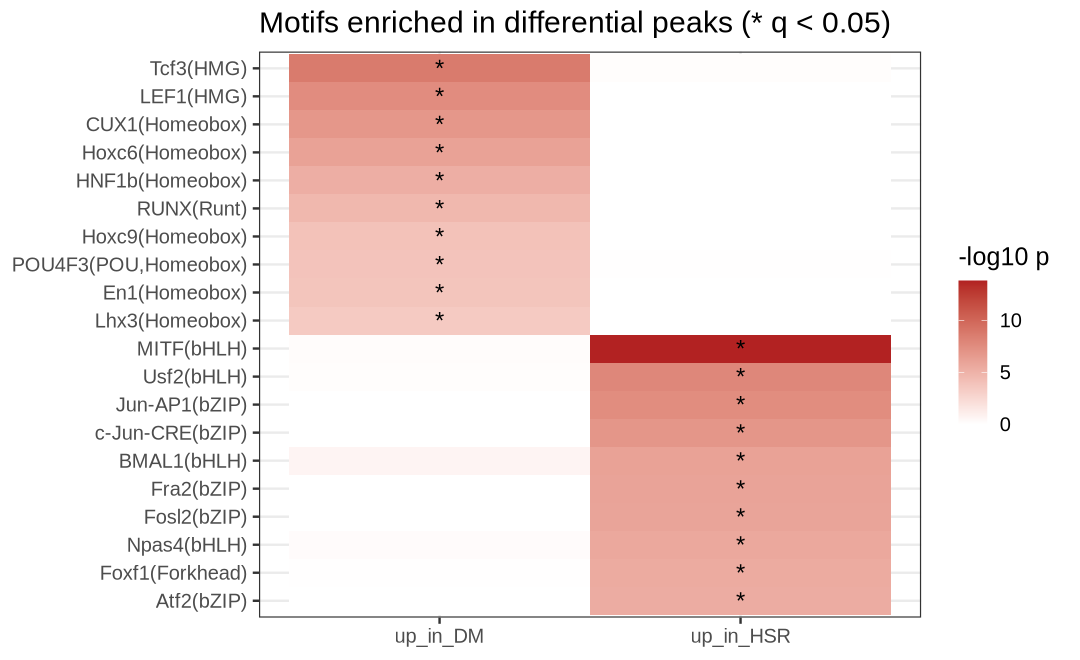

In [19]:
# about 5 minutes for both sets
for (set in c("up_in_DM", "up_in_HSR")) {
    system(sprintf("findMotifs.pl %s.fa fasta homer_%s -fasta background.fa -nomotif -mset vertebrates -p 2 > homer_%s.log 2>&1", set, set, set))
}
read_homer <- function(set) {
    x <- read.delim(sprintf("homer_%s/knownResults.txt", set), check.names = FALSE)
    data.frame(set = set, motif = sub("/.*", "", x[[1]]), log10_p = -x[["Log P-value"]] / log(10),
               q_value = x[["q-value (Benjamini)"]], percent_targets = x[[7]], percent_background = x[[9]])
}
motifs <- rbind(read_homer("up_in_DM"), read_homer("up_in_HSR"))

top <- motifs |> group_by(set) |> slice_max(log10_p, n = 10) |> pull(motif) |> unique()
ggplot(filter(motifs, motif %in% top), aes(set, factor(motif, levels = rev(top)), fill = pmin(log10_p, 30))) +
    geom_tile() + geom_text(aes(label = ifelse(q_value < 0.05, "*", "")), size = 5) +
    scale_fill_gradient(low = "white", high = "firebrick", name = "-log10 p") +
    labs(x = NULL, y = NULL, title = "Motifs enriched in differential peaks (* q < 0.05)")

Peaks up in DM carry TCF/LEF motifs (the TFs of Wnt signaling, central in colorectal cancer), homeobox and RUNX
motifs. Peaks up in HSR carry AP-1 (FOS/JUN) and E-box motifs (MITF, USF).

**✏️ Try it.** Show the logos of the top motifs in each set, or set `search` to a TF name (for example `"CTCF"`,
`"LEF1"`, `"CDX"`) to see where it ranks. (Full report: `homer_up_in_DM/knownResults.html`.)

**#1 Tcf3(HMG)**: in 10.13% of up_in_DM peaks vs 5.30% of background (q < 0.0001)

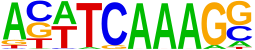

**#2 LEF1(HMG)**: in 17.18% of up_in_DM peaks vs 11.22% of background (q < 0.0001)

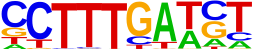

**#3 CUX1(Homeobox)**: in 15.00% of up_in_DM peaks vs 9.69% of background (q < 0.0001)

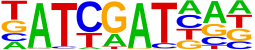

**#4 Hoxc6(Homeobox)**: in 54.72% of up_in_DM peaks vs 46.91% of background (q = 1e-04)

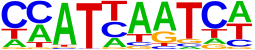

**#5 HNF1b(Homeobox)**: in 5.26% of up_in_DM peaks vs 2.63% of background (q = 5e-04)

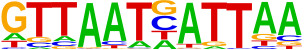

In [20]:
show_set <- "up_in_DM"       # or "up_in_HSR"
show_top <- 5
search <- ""                 # e.g. "CTCF": show where matching motifs rank instead of the top ones

known <- read.delim(sprintf("homer_%s/knownResults.txt", show_set), check.names = FALSE)
rows <- if (search == "") seq_len(show_top) else head(grep(search, known[[1]], ignore.case = TRUE), show_top)
for (i in rows) {
    q <- known[i, "q-value (Benjamini)"]
    IRdisplay::display_markdown(sprintf("**#%d %s**: in %s of %s peaks vs %s of background (q %s)", i,
        sub("/.*", "", known[i, 1]), known[i, 7], show_set, known[i, 9], if (q == 0) "< 0.0001" else paste("=", signif(q, 2))))
    logo <- sprintf("homer_%s/knownResults/known%d.logo.svg", show_set, i)
    if (file.exists(logo)) IRdisplay::display_svg(file = logo) else IRdisplay::display_markdown("(no logo: HOMER draws only its top 60)")
}

## 6. What can we conclude?

- **More reads is not more open.** Copy number explains nearly all of the amplicon's differences: put it in the model to control for it.
- **Per copy, ecDNA comes out about twice as accessible** as the same DNA in a chromosome, reproducing the paper.
- **Beyond the amplicon**, thousands of peaks differ, with different TF programs: Wnt (TCF/LEF), homeobox and RUNX up in DM; AP-1 and E-box up in HSR.
- **Genes near the peaks:** gene-set enrichment is a common next step. Compare the differential peaks with all the peaks you tested. Count peaks, not genes: a gene in a large gene desert collects many peaks. (Not shown here but for this data no gene set stands out.)
- **GC** can be technical or biological. Here it isn't PCR and reproduces in other datasets, but it is not yet clear what it is exactly.
- **An open question:** why are AT-rich sites more open in HSR, and GC-rich ones in DM? What would you check next?